# Music by genre

Classify the genre of a music track using [`sugarblock/music_genres_classification-finetuned-gtzan`](https://huggingface.co/sugarblock/music_genres_classification-finetuned-gtzan), a `facebook/wav2vec2-base-960h` fine-tuned on the GTZAN dataset. GTZAN has 10 genres: blues, classical, country, disco, hiphop, jazz, metal, pop, reggae, rock.

The model expects mono audio at 16 kHz. GTZAN clips are ~30 seconds, so we split each full track into 30-second windows, classify every window, and average the probabilities for a per-track genre profile.

Tracks compared below (everything in `My Drive/google_colab/music_examples`, same files as the emotion / instrument notebooks):
- `Andromida - Real.mp3`
- `Eminem - Lose Yourself.mp3`
- `Linkin Park - In The End.mp3`
- `Nero - Blame You.mp3`
- `Slipknot - Duality.mp3`
- `The Cardigans - My Favorite Game.mp3`

## 1. Install dependencies

In [1]:
!pip install -q transformers torch torchaudio librosa

## 2. Mount Google Drive

After mounting, `My Drive` is available at `/content/drive/MyDrive`.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

AUDIO_DIR = '/content/drive/MyDrive/google_colab/music_examples'
AUDIO_PATHS = [
    f'{AUDIO_DIR}/Andromida - Real.mp3',
    f'{AUDIO_DIR}/Eminem - Lose Yourself.mp3',
    f'{AUDIO_DIR}/Linkin Park - In The End.mp3',
    f'{AUDIO_DIR}/Nero - Blame You.mp3',
    f'{AUDIO_DIR}/Slipknot - Duality.mp3',
    f'{AUDIO_DIR}/The Cardigans - My Favorite Game.mp3',
]

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 3. Load the model and processor

In [3]:
import torch
from transformers import AutoFeatureExtractor, AutoModelForAudioClassification

MODEL_ID = 'sugarblock/music_genres_classification-finetuned-gtzan'

device = 'cuda' if torch.cuda.is_available() else 'cpu'

extractor = AutoFeatureExtractor.from_pretrained(MODEL_ID)
model = AutoModelForAudioClassification.from_pretrained(MODEL_ID).to(device).eval()

# Genre labels come straight from the model config.
GENRE_LABELS = [model.config.id2label[i] for i in range(model.config.num_labels)]

# 16 kHz for wav2vec2
TARGET_SR = extractor.sampling_rate
# GTZAN clips are ~30 seconds; window full tracks to match.
CLIP_SECONDS = 30
CLIP_SAMPLES = TARGET_SR * CLIP_SECONDS

print('Target sampling rate:', TARGET_SR)
print('Clip length:', CLIP_SECONDS, 's', f'({CLIP_SAMPLES} samples)')
print('Genre labels:', GENRE_LABELS)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/223 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/2.69k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/215 [00:00<?, ?it/s]

Target sampling rate: 16000
Clip length: 30 s (480000 samples)
Genre labels: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']


## 4. Inference helper

Load a track (mono, 16 kHz), split it into non-overlapping 30-second windows, run
the model on every window, and average the softmax probabilities across
windows. The result is a per-track genre distribution plus the per-window top
predictions (so we can see how the genre call shifts over the track).

In [4]:
import os
import numpy as np
import librosa


def classify(path, batch_size=8):
    """Return (mean_probs, window_top_ids, duration_seconds) for one audio file.

    The track is chopped into non-overlapping 30-second windows; the last,
    shorter window is kept only if it holds at least 5 seconds of audio.
    """
    waveform, sr = librosa.load(path, sr=TARGET_SR, mono=True)
    duration = len(waveform) / sr

    # Split into 30-second windows; drop a tiny trailing remnant (< 5 s).
    windows = []
    for start in range(0, len(waveform), CLIP_SAMPLES):
        clip = waveform[start:start + CLIP_SAMPLES]
        if len(clip) < 5 * TARGET_SR:
            continue
        windows.append(clip)
    if not windows:                      # very short track: use the whole thing
        windows = [waveform]

    all_probs = []
    for i in range(0, len(windows), batch_size):
        batch = windows[i:i + batch_size]
        inputs = extractor(batch, sampling_rate=TARGET_SR, return_tensors='pt',
                           padding=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        with torch.no_grad():
            logits = model(**inputs).logits
        all_probs.append(torch.softmax(logits, dim=-1).cpu())

    probs = torch.cat(all_probs, dim=0)        # (n_windows, n_labels)
    mean_probs = probs.mean(dim=0)             # (n_labels,)
    window_top_ids = probs.argmax(dim=-1)      # (n_windows,)
    return mean_probs, window_top_ids, duration


# Classify every track once; the cells below just read `results`.
results = {}
window_preds = {}
for path in AUDIO_PATHS:
    name = os.path.splitext(os.path.basename(path))[0]
    mean_probs, top_ids, duration = classify(path)
    results[name] = mean_probs
    window_preds[name] = top_ids
    print(f'{name}: {duration:.1f}s ({len(top_ids)} windows)')

Andromida - Real: 218.1s (8 windows)
Eminem - Lose Yourself: 326.5s (11 windows)
Linkin Park - In The End: 219.0s (8 windows)
Nero - Blame You: 200.5s (7 windows)
Slipknot - Duality: 218.6s (8 windows)


/tmp/ipykernel_19001/765101610.py:12: UserWarning: PySoundFile failed. Trying audioread instead.
  waveform, sr = librosa.load(path, sr=TARGET_SR, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


The Cardigans - My Favorite Game: 216.3s (8 windows)


## 5. Top prediction per track

The single most likely genre (averaged over the whole track) plus the share of
30-second windows where it was the top pick.

In [5]:
for name, probs in results.items():
    top_id = int(probs.argmax())
    top_ids = window_preds[name]
    window_share = (top_ids == top_id).float().mean().item()
    print(f'{name}')
    print(f'  Predicted genre: {GENRE_LABELS[top_id]} '
          f'({probs[top_id].item():.2%} mean prob, '
          f'top in {window_share:.0%} of windows)\n')

Andromida - Real
  Predicted genre: pop (64.45% mean prob, top in 75% of windows)

Eminem - Lose Yourself
  Predicted genre: hiphop (69.98% mean prob, top in 73% of windows)

Linkin Park - In The End
  Predicted genre: hiphop (42.53% mean prob, top in 38% of windows)

Nero - Blame You
  Predicted genre: pop (97.09% mean prob, top in 100% of windows)

Slipknot - Duality
  Predicted genre: metal (86.37% mean prob, top in 88% of windows)

The Cardigans - My Favorite Game
  Predicted genre: pop (37.07% mean prob, top in 38% of windows)



## 6. Side-by-side comparison

Full per-genre mean probabilities for all six tracks, sorted by the first track's scores.

In [6]:
import pandas as pd

comparison = pd.DataFrame(
    {name: [probs[i].item() for i in range(len(GENRE_LABELS))]
     for name, probs in results.items()},
    index=GENRE_LABELS,
)
comparison.index.name = 'genre'

# Sort by the first track so the table is easier to scan.
comparison = comparison.sort_values(by=comparison.columns[0], ascending=False)

(comparison * 100).round(2).style.format('{:.2f}%')

,Andromida - Real,Eminem - Lose Yourself,Linkin Park - In The End,Nero - Blame You,Slipknot - Duality,The Cardigans - My Favorite Game
genre,,,,,,
pop,64.45%,0.13%,6.45%,97.09%,0.05%,37.07%
disco,14.83%,9.42%,0.51%,0.81%,0.04%,12.36%
classical,12.54%,9.24%,0.31%,0.15%,12.42%,0.10%
hiphop,6.92%,69.98%,42.53%,0.86%,0.20%,7.91%
country,0.39%,0.14%,0.27%,0.52%,0.03%,0.45%
rock,0.24%,0.28%,11.94%,0.24%,0.45%,3.84%
reggae,0.22%,1.78%,0.32%,0.06%,0.11%,1.81%
blues,0.20%,8.75%,0.24%,0.14%,0.10%,0.30%
jazz,0.13%,0.05%,12.49%,0.11%,0.24%,0.22%


## 7. Genre timeline

How the per-window top genre changes across each track.

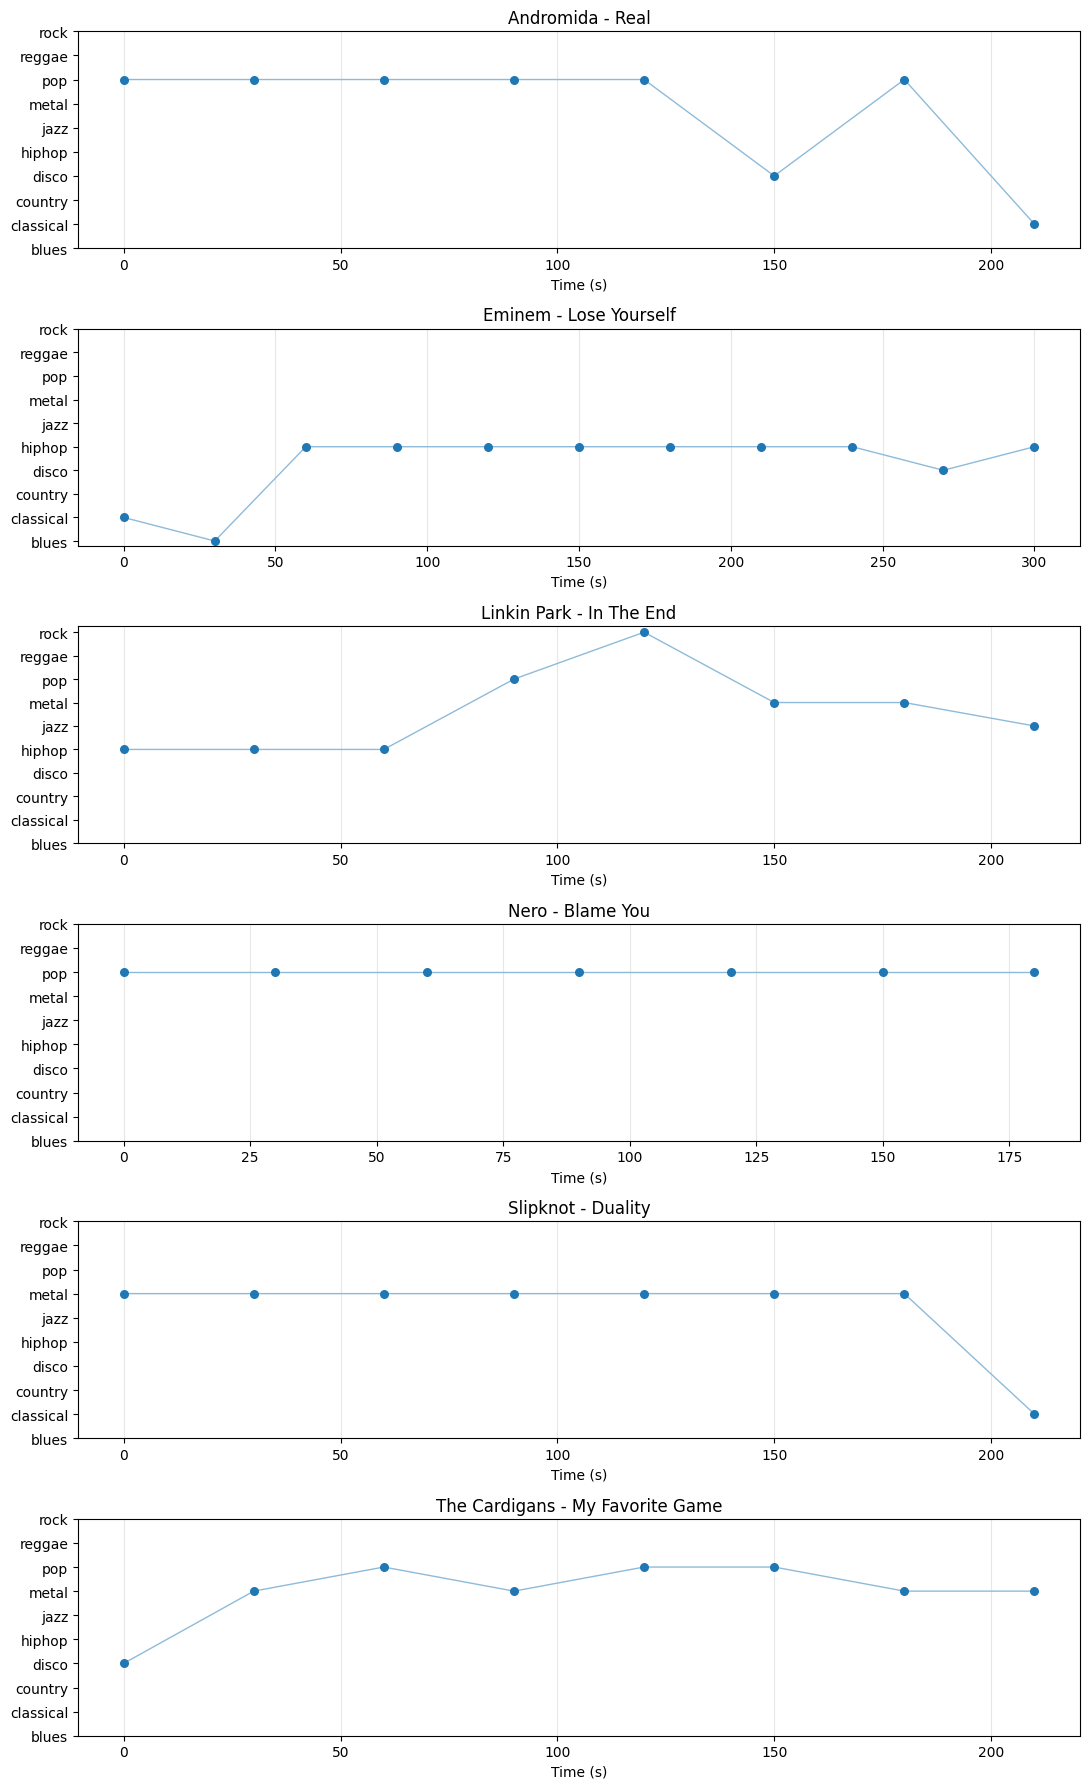

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(window_preds), 1, figsize=(11, 3 * len(window_preds)),
                         squeeze=False)
for ax, (name, top_ids) in zip(axes[:, 0], window_preds.items()):
    times = np.arange(len(top_ids)) * CLIP_SECONDS
    ax.plot(times, top_ids.numpy(), linewidth=1, alpha=0.5, zorder=1)
    ax.scatter(times, top_ids.numpy(), s=30, zorder=2)
    ax.set_yticks(range(len(GENRE_LABELS)))
    ax.set_yticklabels(GENRE_LABELS)
    ax.set_xlabel('Time (s)')
    ax.set_title(name)
    ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.show()